# 01 · Trayectorias — Pruebas APRENDER y Estadística Educativa

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]
(https://colab.research.google.com/github/santiagoriverti/analisis_pruebas_aprender/blob/main/01_analisis.ipynb)

Visualización **descriptiva** de la evolución en el tiempo de las variables más relevantes.
Consume el dataset de [`00_consolidacion.ipynb`](00_consolidacion.ipynb): en **Colab** lee desde
*Mi unidad/`pruebas_aprender/parquet`*; en **local**, desde `datos_consolidados/`.

## Regla de comparabilidad (define qué se puede graficar como serie)

- **RA — Relevamiento Anual (2011–2025):** mismo diseño todos los años → **series de tiempo válidas**
  (matrícula, trayectoria escolar, cargos docentes, población, infraestructura).
- **APRENDER (2016–2025):** el operativo **cambia de grado/nivel/cobertura** cada año → **no** hay
  serie continua; solo se compara dentro de la misma `(nivel, grado, cobertura)`:
  - **Primaria 6° grado – Censal:** 2021 → 2023 → 2025.
  - **Secundaria 5-6° año – Censal:** 2019 → 2022 → 2024.
  - Escala de desempeño homogénea (4 niveles) salvo Primaria 3° 2024.

---
## 0 · Setup y carga

In [1]:
import os, re, unicodedata
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

def in_colab():
    try:
        import google.colab  # noqa
        return True
    except ImportError:
        return False

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    OUT = '/content/drive/MyDrive/pruebas_aprender/parquet'
else:
    OUT = os.path.join(os.getcwd(), 'datos_consolidados')
assert os.path.isdir(os.path.join(OUT, 'aprender_long')), (
    f'No encuentro el dataset en {OUT}. Corré primero 00_consolidacion.ipynb.')
plt.rcParams['figure.dpi'] = 110
print('Datos consolidados en:', OUT)

Datos consolidados en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\datos_consolidados


---
## 1 · Funciones

In [2]:
def cargar_ra(base):
    return pd.read_parquet(os.path.join(OUT, 'ra', f'ra_{base}.parquet'))
def cargar_aprender(anio, cols=None):
    return pd.read_parquet(os.path.join(OUT, 'aprender_long', f'anio={anio}'), columns=cols)

# --- RA: sumar columnas por año de estudio (rangos: primaria 1-6, secundaria 7-12) ---
PRIM, SEC = range(1, 7), range(7, 13)
def suma_anios(df, prefijo, anios_estudio):
    cols = [f'{prefijo}_{i}' for i in anios_estudio if f'{prefijo}_{i}' in df.columns]
    return df.groupby('anio')[cols].sum().sum(axis=1)
def tasa(df, numerador, anios_estudio):
    return (suma_anios(df, numerador, anios_estudio) / suma_anios(df, 'inicial', anios_estudio) * 100)

# --- APRENDER: armonización de niveles de desempeño (escala de 4) ---
ORDEN4 = ['Por debajo del básico', 'Básico', 'Satisfactorio', 'Avanzado']
def _n(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii','ignore').decode().lower()
    return re.sub(r'[^a-z0-9]+', ' ', s).strip()
def harmonizar_nivel(op):
    t = _n(op)
    if 'por debajo' in t: return 'Por debajo del básico'
    if t == 'basico': return 'Básico'
    if 'satisfactorio' in t: return 'Satisfactorio'
    if 'avanzado' in t: return 'Avanzado'
    return None
def cargar_desempeno(anio):
    d = cargar_aprender(anio)
    d = d[d.tipo_variable == 'desempeño'].copy()
    d['nivel_desemp'] = d['variable'].str.split('_', n=1).str[1].map(harmonizar_nivel)
    d['anio'] = anio
    return d
def desempeno_pct(df, group_cols):
    d = df.dropna(subset=['nivel_desemp'])
    t = (d.groupby(list(group_cols) + ['nivel_desemp'], observed=True)['valor'].sum()
           .unstack('nivel_desemp').reindex(columns=ORDEN4))
    return t.div(t.sum(axis=1), axis=0) * 100
def serie_cohorte(nivel, grado, cobertura, area, anios):
    df = pd.concat([cargar_desempeno(a) for a in anios], ignore_index=True)
    coh = df[(df.nivel==nivel)&(df.grado==grado)&(df.cobertura==cobertura)&(df.area==area)]
    return desempeno_pct(coh, ['anio'])
print('Funciones listas.')

Funciones listas.


---
## 2 · Mapa de comparabilidad (cohortes APRENDER)
Matriz `(nivel, grado, cobertura, área) × año`. Las filas con varias `X` en la misma cobertura son
las series comparables.

In [3]:
filas = []
for a in sorted(os.listdir(os.path.join(OUT, 'aprender_long'))):
    anio = int(a.split('=')[1])
    d = cargar_aprender(anio, cols=['cobertura','nivel','grado','area','tipo_variable'])
    for k, _ in d[d.tipo_variable=='desempeño'].groupby(['nivel','grado','cobertura','area'], observed=True):
        filas.append((*k, anio))
mapa = pd.DataFrame(filas, columns=['nivel','grado','cobertura','area','anio'])
mapa.assign(x='X').pivot_table(index=['nivel','grado','cobertura','area'], columns='anio',
        values='x', aggfunc='first', observed=True).fillna('')

anio                                                         2016 2017 2018  \
nivel           grado           cobertura area                                
No especificado No especificado Censal    Lengua                          X   
                                          Matematica                      X   
Primaria        3 grado         Muestral  Lengua                              
                3grado          Muestral  Lengua                X             
                                          Matematica            X             
                6 grado         Censal    Lengua                              
                                          Matematica                          
                                Muestral  Lengua                              
                                          Matematica                          
                No especificado Censal    Ciencias Naturales         X        
                                          Ciencias Sociales          X        
                                          Lengua                X             
                                          Matematica            X             
Secundaria      2-3 año         Muestral  Lengua                X             
                                          Matematica            X             
                5-6 año         Censal    Lengua                              
                                          Matematica                          
                                Muestral  Ciencias Naturales                  
                                          Ciudadania                          
                No especificado Censal    Ciencias Naturales    X             
                                          Ciencias Sociales     X             
                                          Lengua                X    X        
                                          Matematica            X    X        

anio                                                         2019 2021 2022  \
nivel           grado           cobertura area                                
No especificado No especificado Censal    Lengua                              
                                          Matematica                          
Primaria        3 grado         Muestral  Lengua                              
                3grado          Muestral  Lengua                              
                                          Matematica                          
                6 grado         Censal    Lengua                     X        
                                          Matematica                 X        
                                Muestral  Lengua                          X   
                                          Matematica                      X   
                No especificado Censal    Ciencias Naturales                  
                                          Ciencias Sociales                   
                                          Lengua                              
                                          Matematica                          
Secundaria      2-3 año         Muestral  Lengua                              
                                          Matematica                          
                5-6 año         Censal    Lengua                X         X   
                                          Matematica            X         X   
                                Muestral  Ciencias Naturales    X             
                                          Ciudadania            X             
                No especificado Censal    Ciencias Naturales                  
                                          Ciencias Sociales                   
                                          Lengua                              
                                          Matematica                          

anio                                            

---
# A · Trayectorias de estadística educativa (RA, 2011–2025)

### A.1 · Matrícula inicial por nivel
La matrícula **secundaria crece** (expansión de cobertura) mientras la primaria se mantiene.

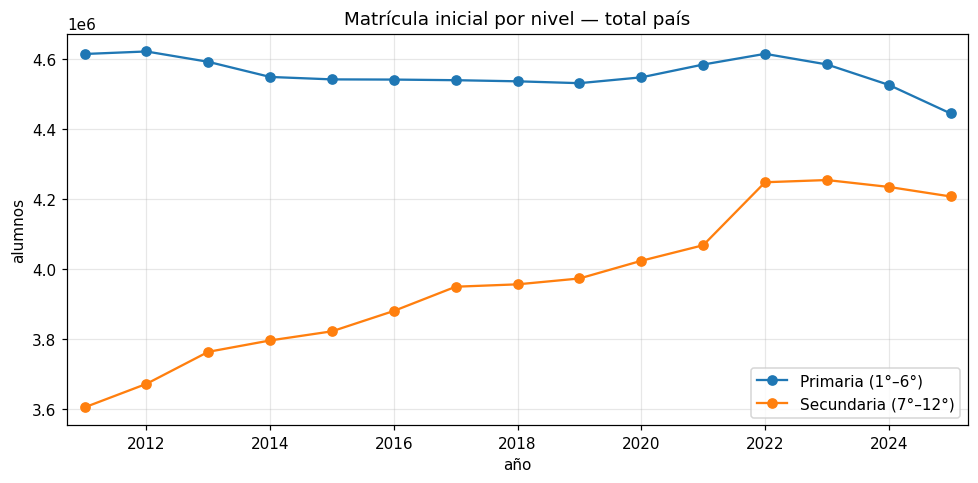

,Primaria (1°–6°),Secundaria (7°–12°)
anio,,
2011,4.61,3.61
2012,4.62,3.67
2013,4.59,3.76
2014,4.55,3.80
2015,4.54,3.82
2016,4.54,3.88
2017,4.54,3.95
2018,4.54,3.96
2019,4.53,3.97


In [4]:
tr = cargar_ra('trayectoria')
mat = pd.DataFrame({'Primaria (1°–6°)': suma_anios(tr, 'inicial', PRIM),
                    'Secundaria (7°–12°)': suma_anios(tr, 'inicial', SEC)})
ax = mat.plot(marker='o', figsize=(9,4.5), title='Matrícula inicial por nivel — total país')
ax.set_xlabel('año'); ax.set_ylabel('alumnos'); ax.grid(alpha=.3); ax.margins(x=.02)
plt.tight_layout(); plt.show()
(mat/1e6).round(2)

### A.2 · Tasa de repitencia y de abandono
Repitencia = `no promovidos / matrícula inicial`; abandono = `salidos sin pase / matrícula inicial`.
Ambas **bajan** en el período, sobre todo en secundaria.

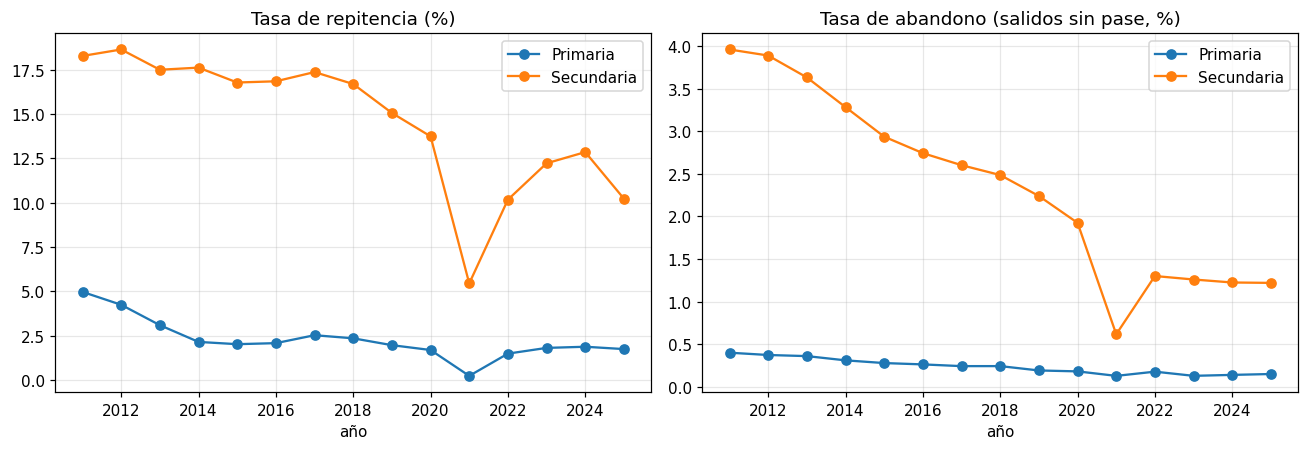

repitencia            abandono           
       Primaria Secundaria Primaria Secundaria
anio                                          
2011        5.0       18.3      0.4        4.0
2012        4.2       18.7      0.4        3.9
2013        3.1       17.5      0.4        3.6
2014        2.1       17.6      0.3        3.3
2015        2.0       16.8      0.3        2.9
2016        2.1       16.9      0.3        2.7
2017        2.5       17.4      0.2        2.6
2018        2.3       16.7      0.2        2.5
2019        2.0       15.1      0.2        2.2
2020        1.7       13.7      0.2        1.9
2021        0.2        5.4      0.1        0.6
2022        1.5       10.2      0.2        1.3
2023        1.8       12.2      0.1        1.3
2024        1.9       12.9      0.1        1.2
2025        1.7       10.2      0.2        1.2

In [5]:
rep = pd.DataFrame({'Primaria': tasa(tr, 'nopromo', PRIM), 'Secundaria': tasa(tr, 'nopromo', SEC)})
aba = pd.DataFrame({'Primaria': tasa(tr, 'ssp', PRIM), 'Secundaria': tasa(tr, 'ssp', SEC)})
fig, ax = plt.subplots(1, 2, figsize=(12,4.2), sharex=True)
rep.plot(marker='o', ax=ax[0], title='Tasa de repitencia (%)'); ax[0].grid(alpha=.3); ax[0].set_xlabel('año')
aba.plot(marker='o', ax=ax[1], title='Tasa de abandono (salidos sin pase, %)'); ax[1].grid(alpha=.3); ax[1].set_xlabel('año')
plt.tight_layout(); plt.show()
pd.concat({'repitencia': rep.round(1), 'abandono': aba.round(1)}, axis=1)

### A.3 · Cargos docentes
Total de cargos/horas docentes (base *Cargos Bis*), en aumento sostenido.

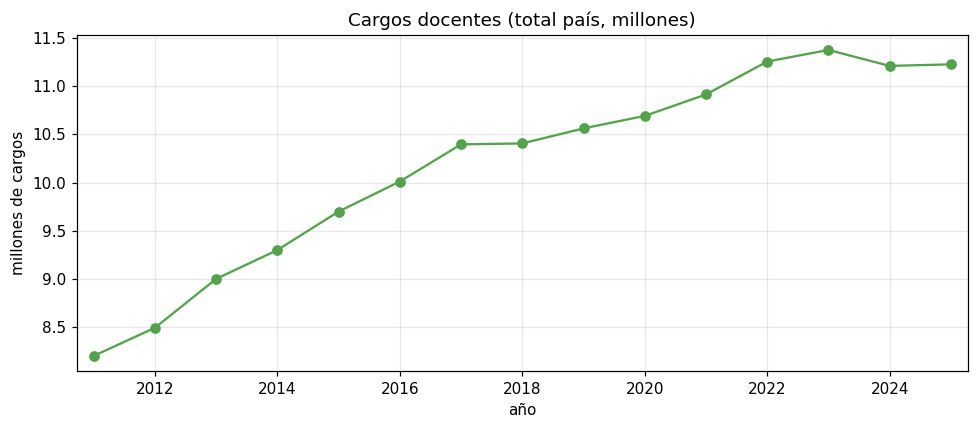

anio
2011     8205339
2012     8496613
2013     9002773
2014     9301562
2015     9700439
2016    10011295
2017    10396044
2018    10405749
2019    10561421
2020    10690757
2021    10912885
2022    11253497
2023    11373727
2024    11208635
2025    11224704
Name: total, dtype: int64

In [6]:
cb = cargar_ra('cargos_bis')
serie_cargos = cb.groupby('anio')['total'].sum()
ax = (serie_cargos/1e6).plot(marker='o', color='#54A24B', figsize=(9,4),
     title='Cargos docentes (total país, millones)')
ax.set_xlabel('año'); ax.set_ylabel('millones de cargos'); ax.grid(alpha=.3); ax.margins(x=.02)
plt.tight_layout(); plt.show()
serie_cargos.astype(int)

---
# B · Trayectorias de desempeño (APRENDER, cohortes comparables)
Solo dentro de la misma `(nivel, grado, cobertura)`. `valor` = conteo ponderado → se convierte a %.

### B.1 · Primaria 6° grado (Censal): 2021 · 2023 · 2025

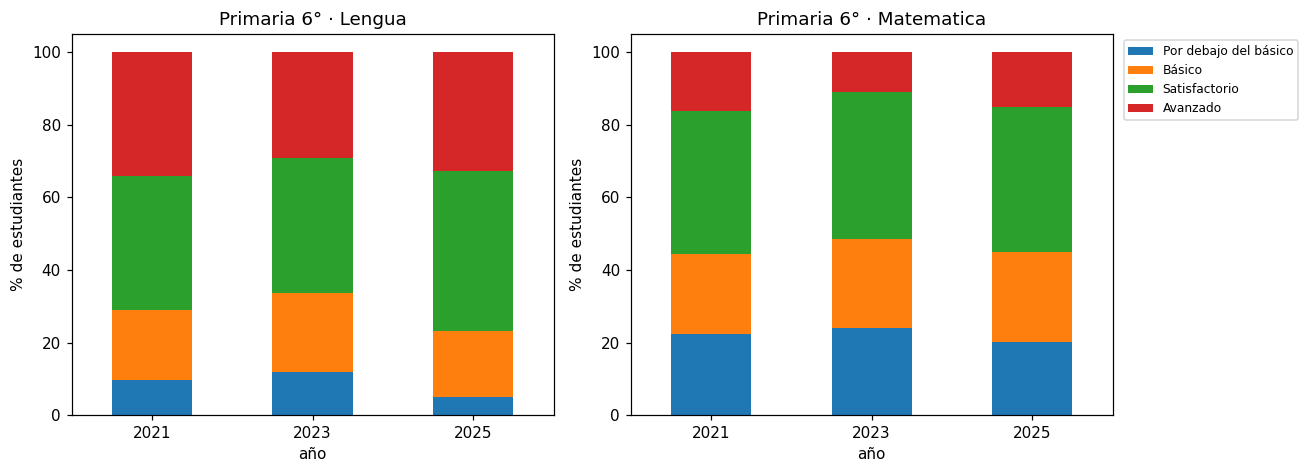

% Satisfactorio+Avanzado — Primaria 6°:


,Lengua,Matematica
anio,,
2021,70.9,55.5
2023,66.4,51.4
2025,76.9,55.0


In [7]:
anios_p = [2021, 2023, 2025]
fig, ax = plt.subplots(1, 2, figsize=(12,4.4))
for i, area in enumerate(['Lengua', 'Matematica']):
    s = serie_cohorte('Primaria', '6 grado', 'Censal', area, anios_p)
    s.plot(kind='bar', stacked=True, ax=ax[i], title=f'Primaria 6° · {area}')
    ax[i].set_xlabel('año'); ax[i].set_ylabel('% de estudiantes'); ax[i].tick_params(axis='x', rotation=0)
    ax[i].legend().set_visible(i==1)
if ax[1].get_legend(): ax[1].legend(bbox_to_anchor=(1.01,1), fontsize=8)
plt.tight_layout(); plt.show()
# Resumen: % Satisfactorio+Avanzado por año y área
resumen_p = pd.DataFrame({area: serie_cohorte('Primaria','6 grado','Censal',area,anios_p)[['Satisfactorio','Avanzado']].sum(axis=1)
                          for area in ['Lengua','Matematica']})
print('% Satisfactorio+Avanzado — Primaria 6°:'); resumen_p.round(1)

### B.2 · Secundaria 5-6° año (Censal): 2019 · 2022 · 2024

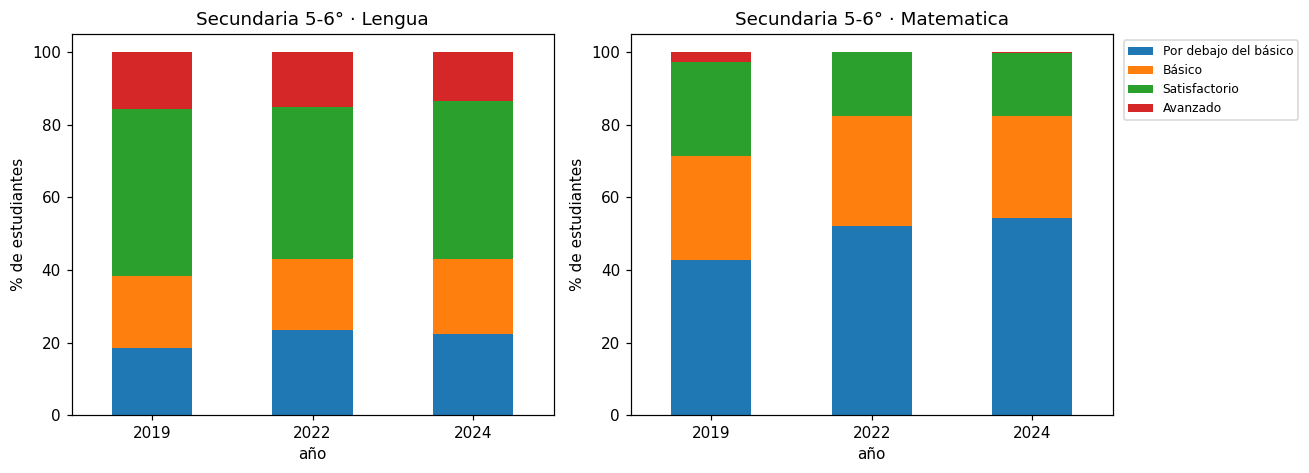

% Satisfactorio+Avanzado — Secundaria 5-6°:


,Lengua,Matematica
anio,,
2019,61.8,28.7
2022,56.9,17.6
2024,56.9,17.6


In [8]:
anios_s = [2019, 2022, 2024]
fig, ax = plt.subplots(1, 2, figsize=(12,4.4))
for i, area in enumerate(['Lengua', 'Matematica']):
    s = serie_cohorte('Secundaria', '5-6 año', 'Censal', area, anios_s)
    s.plot(kind='bar', stacked=True, ax=ax[i], title=f'Secundaria 5-6° · {area}')
    ax[i].set_xlabel('año'); ax[i].set_ylabel('% de estudiantes'); ax[i].tick_params(axis='x', rotation=0)
    ax[i].legend().set_visible(i==1)
if ax[1].get_legend(): ax[1].legend(bbox_to_anchor=(1.01,1), fontsize=8)
plt.tight_layout(); plt.show()
resumen_s = pd.DataFrame({area: serie_cohorte('Secundaria','5-6 año','Censal',area,anios_s)[['Satisfactorio','Avanzado']].sum(axis=1)
                          for area in ['Lengua','Matematica']})
print('% Satisfactorio+Avanzado — Secundaria 5-6°:'); resumen_s.round(1)

### B.3 · La trayectoria por sector (Estatal vs Privado)
Descriptivo: cómo evoluciona el % (Satisfactorio+Avanzado) por sector dentro de una cohorte.

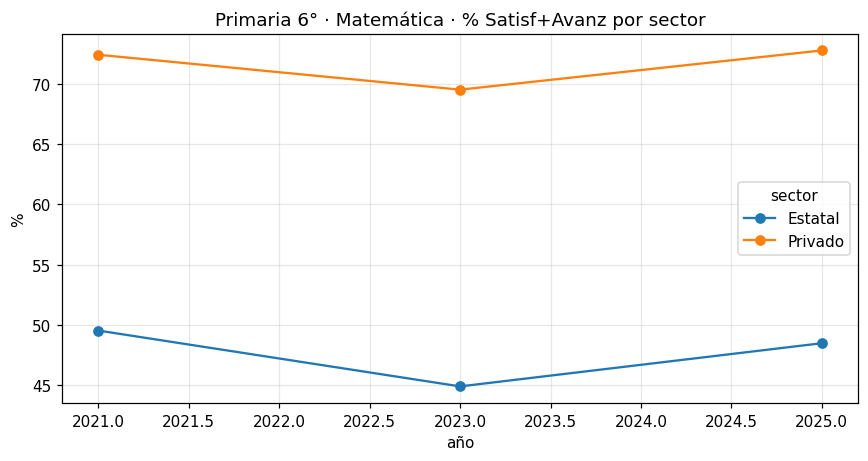

sector,Estatal,Privado
anio,,
2021,49.5,72.4
2023,44.9,69.5
2025,48.5,72.7


In [9]:
def serie_sector(nivel, grado, cobertura, area, anios):
    df = pd.concat([cargar_desempeno(a) for a in anios], ignore_index=True)
    coh = df[(df.nivel==nivel)&(df.grado==grado)&(df.cobertura==cobertura)&(df.area==area)]
    pct = desempeno_pct(coh, ['anio','sector'])
    return (pct[['Satisfactorio','Avanzado']].sum(axis=1)).unstack('sector')
g = serie_sector('Primaria','6 grado','Censal','Matematica',[2021,2023,2025])
ax = g.plot(marker='o', figsize=(8,4.3), title='Primaria 6° · Matemática · % Satisf+Avanz por sector')
ax.set_xlabel('año'); ax.set_ylabel('%'); ax.grid(alpha=.3); ax.margins(x=.05); plt.tight_layout(); plt.show()
g.round(1)

---
## Cómo extender

- **Otras cohortes/áreas:** `serie_cohorte('Secundaria','5-6 año','Censal','Lengua',[2019,2022,2024])`.
- **Más trayectorias RA:** promoción (`tasa(tr,'promovidos',PRIM)`), sobreedad (base *Matrícula por edad*),
  población/infraestructura (base *Características*).
- **Cortes geográficos:** filtrar por `provincia`/`jurisdiccion` antes de agregar.
- **Diccionario:** `pd.read_parquet(f'{OUT}/diccionario_ra.parquet')` y `.../diccionario_aprender.parquet`.

> Unidades: APRENDER = conteos **ponderados** (se pasan a % por celda); RA = conteos **absolutos**.
> No comparar cohortes APRENDER de distinto grado/nivel entre sí.